# M4 | Research Investigation Notebook

In this notebook, you will do a research investigation of your chosen dataset in teams. You will begin by formally selecting your research question (task 0), then processing your data (task 1), creating a predictive model (task 2), evaluating your model's results (task 3), and describing the contributions of each team member (task 4).

For grading, please make sure your notebook has all cells already run. You will also need to write a short, 2 page report about your design decisions as a team, to be uploaded to Moodle in the form of a PDF file next to this Jupyter notebook.

You should provide arguments and justifications for all of your design decisions throughout this investigation. You can use your M3 responses as the basis for this discussion.

In [2]:
# Import the tables of the data set as dataframes.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = './data' # You many change the directory

# Other main package imports
import seaborn as sns
import scipy as sc

# Scikit-learn package imports
from sklearn import feature_extraction, model_selection
from sklearn.metrics import root_mean_squared_error, mean_squared_error, roc_auc_score

# PyBKT package imports
import random
old_randint = random.randint
random.randint = lambda a, b: old_randint(a, int(b))
from pyBKT.models import Model
random.randint = old_randint

## Task 0: Research Question

**Research question:**
*How does AI model usage by students affect their learning?*

## Task 1: Data Preprocessing

In this section, you are asked to preprocess your data in a way that is relevant for the model. Please include 1-2 visualizations of features / data explorations that are related to your downstream prediction task.

In [3]:
# 1. Map gymitrainer data to rest of tables 
gymitrainer_df = pd.read_csv("updated_data/gymitrainer.csv")
gymitrainer_df = gymitrainer_df.drop(columns=['chat_profile'])
#display(gymitrainer_df.head())
mapping_df = pd.read_csv("updated_data/mapping.csv")
#display(mapping_df.head())

threshold = 0.5
filtered_mapping = mapping_df[mapping_df['confidence'] >= threshold]

# Contains only users where the matching is confident enough and who 
# used the chatbot at all (since they appear in gymitrainer.csv)
# Inner merging guarantees that we only have people who used the chatbot
matched_gymitrainer = pd.merge(
    gymitrainer_df,
    filtered_mapping[['id', 'user_id']],
    on='id',
    how='inner'  
)

tag_replacements = {
    'Mathehilfe': 'Mathe',
    'math_help': 'Mathe',
    'essay_writing': 'Aufsatz',
    'Aufsatzhilfe': 'Aufsatz',
    'Sprachprufung': 'Sprache',
    'text_comprehension': 'Sprache'
}

matched_gymitrainer['tag'] = matched_gymitrainer['tag'].replace(tag_replacements)

def fill_missing_tag(row):
    if pd.isna(row['tag']) or row['tag'] == '':
        content = str(row['content'])
        if content.startswith("['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor") or \
           content.startswith("['Hallo! Mein Name ist Gymitrainer, und ich bin dein Mathe-Guru"):
            return 'Mathe'
        elif content.startswith("['Hey! Ich bin Gymitrainer, dein Experte für Gymi-Prüfungsaufsätze"):
            return 'Aufsatz'
        else:
            return row['tag']  # Leave it missing if none of the patterns match
    else:
        return row['tag']

matched_gymitrainer['tag'] = matched_gymitrainer.apply(fill_missing_tag, axis=1)

matched_gymitrainer = matched_gymitrainer.sort_values(by='user_id')
#display(matched_gymitrainer.head())   



# 2. Remove potential teachers from the dataset as a safety 
# (we only want to study learning on students)
teachers = pd.read_csv("updated_data/teachers.csv")
teacher_ids = teachers['user_id'].unique()
matched_gymitrainer = matched_gymitrainer[~matched_gymitrainer['user_id'].isin(teacher_ids)].copy()



# 3. Prepare a large DataFrame "all_data" to work with when building KT models
math_results = pd.read_csv("updated_data/math_results.csv")
math_results_clean = math_results.copy()
math_results_clean['timestamp'] = pd.to_datetime(math_results_clean['time'], unit='s')
math_results_clean['skill_id'] = math_results_clean['question'].astype(str)  # Assume question ID as a skill
math_results_clean['correct'] = math_results_clean['correct'].astype(int)
math_results_clean['hint_used'] = (math_results_clean['hint_count'] > 0).astype(int)

essay_results = pd.read_csv("updated_data/essay_results.csv")
essay_results_clean = essay_results.copy()
essay_results_clean['timestamp'] = pd.to_datetime(essay_results_clean['time'], unit='s')
essay_skill_columns = [col for col in essay_results.columns if '-' in col or col.startswith('content') or col.startswith('structure') or col.startswith('language')]
essay_results_clean['skill_score'] = essay_results_clean[essay_skill_columns].mean(axis=1)
essay_results_clean['correct'] = (essay_results_clean['skill_score'] >= 6).astype(int)
essay_results_clean['skill_id'] = essay_results_clean['textType']  # Treat text type (e.g. "erzaehlung") as a skill

text_results = pd.read_csv("updated_data/text_results.csv")
text_results_clean = text_results.copy()
text_results_clean['timestamp'] = pd.to_datetime(text_results_clean['time'], unit='s')
text_results_clean['skill_id'] = text_results_clean['exam_id'].astype(str) + '-' + text_results_clean['question'].astype(str)
text_results_clean['correct'] = (text_results_clean['points'] / text_results_clean['max_points']) >= 0.5
text_results_clean['correct'] = text_results_clean['correct'].astype(int) 

math_data = math_results_clean[['user_id', 'skill_id', 'correct', 'timestamp', 'hint_used']].copy()
essay_data = essay_results_clean[['user_id', 'skill_id', 'correct', 'timestamp']].copy()
text_data = text_results_clean[['user_id', 'skill_id', 'correct', 'timestamp']].copy()

essay_data['hint_used'] = 0
text_data['hint_used'] = 0

math_data['domain'] = 'math'
essay_data['domain'] = 'essay'
text_data['domain'] = 'text'


print(math_data)

       user_id skill_id  correct           timestamp  hint_used domain
0         2437        1        0 2022-10-06 14:51:55          0   math
1         2437        2        0 2022-10-06 15:15:10          0   math
2         2437        3        0 2022-10-06 15:39:19          0   math
3         2437        6        0 2022-10-06 16:38:50          0   math
4         2437        7        0 2022-10-06 16:38:50          0   math
...        ...      ...      ...                 ...        ...    ...
56802      955      869        1 2025-03-07 06:54:21          0   math
56803      955      870        1 2025-03-07 06:54:21          0   math
56804      955      871        1 2025-03-07 06:54:21          0   math
56805      955      872        1 2025-03-07 06:54:21          1   math
56806      955      873        1 2025-03-07 06:54:21          1   math

[56807 rows x 6 columns]


In [4]:
subject_tags = ['Mathe', 'Aufsatz', 'Sprache']

#Count number of times each student used the chatbot for each subject/tag
ai_usage_per_subject = matched_gymitrainer[matched_gymitrainer['tag'].isin(subject_tags)].groupby(['user_id', 'tag']).size().unstack(fill_value=0)
for subject in subject_tags:
    if subject not in ai_usage_per_subject.columns:
        ai_usage_per_subject[subject] = 0
print(ai_usage_per_subject)

tag      Aufsatz  Mathe  Sprache
user_id                         
4              1      0        0
6              2      7        0
7              0      2        0
9              0      4        0
11             0      3        0
...          ...    ...      ...
4085           2      0        0
4086           3      5        0
4087           1      8        0
4089           1      1        0
4095           0      4        0

[532 rows x 3 columns]


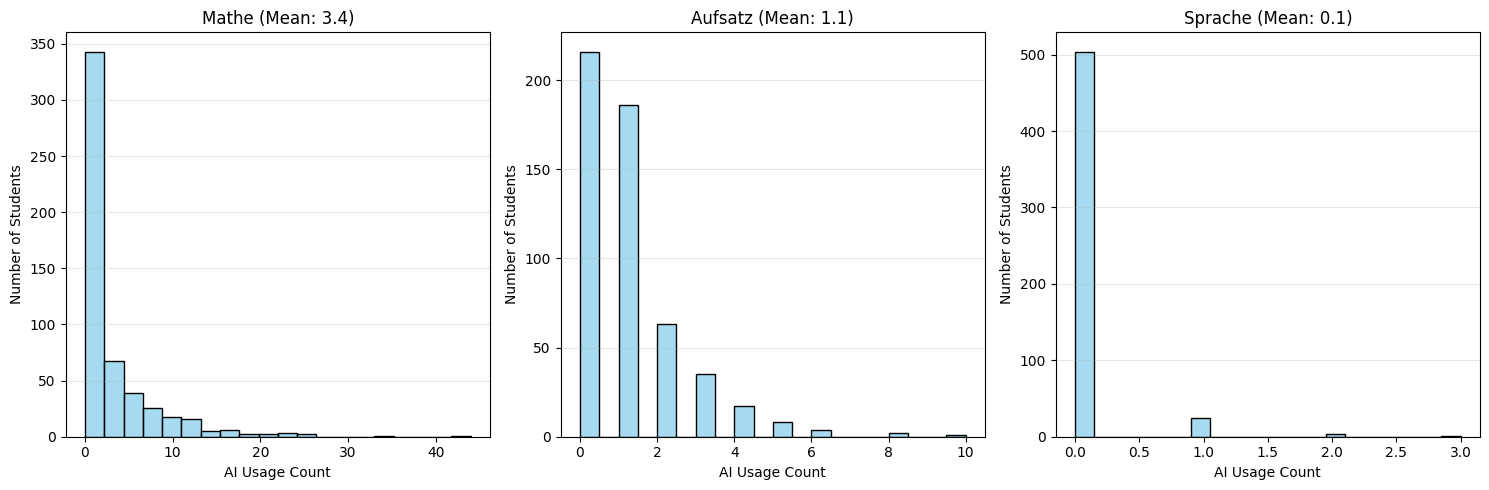

In [5]:
plt.figure(figsize=(15, 5))
for i, subject in enumerate(subject_tags, 1):
    toplot = ai_usage_per_subject[subject]
    if(subject == "Mathe"):
        toplot = ai_usage_per_subject[subject].nsmallest(len(ai_usage_per_subject[subject]) -1 )
    plt.subplot(1, 3, i)
    sns.histplot(toplot, bins=20, kde=False, color='skyblue')
    plt.title(f'{subject} (Mean: {ai_usage_per_subject[subject].mean():.1f})')
    plt.xlabel('AI Usage Count')
    plt.ylabel('Number of Students')
    plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
def compute_threshold(series, percentile=75):
    """Compute a single percentile threshold from non-zero values."""
    non_zero = series[series > 0]
    return np.percentile(non_zero, percentile) if len(non_zero) > 0 else 0

def categorize_usage(count, threshold):
    if count == 0:
        return 'non_ai_user'
    elif count <= threshold:
        return 'light_ai_user'
    else:
        return 'heavy_ai_user'

# Set your cutoff percentile here (e.g., 75 for top 25% = heavy users)
cutoff_percentile = 75

for subject in subject_tags:
    threshold = compute_threshold(ai_usage_per_subject[subject], percentile=cutoff_percentile)
    ai_usage_per_subject[f'{subject}_ai_usage_category'] = ai_usage_per_subject[subject].apply(
        lambda x: categorize_usage(x, threshold)
    )

print("# of Messages for each User, by Subject", ai_usage_per_subject[[f'{s}_ai_usage_category' for s in subject_tags]].head())

math_data_with_ai = math_data.merge(
    ai_usage_per_subject[['Mathe', 'Mathe_ai_usage_category']], 
    on='user_id', 
    how='left'
)

essay_data_with_ai = essay_data.merge(
    ai_usage_per_subject[['Aufsatz', 'Aufsatz_ai_usage_category']], 
    on='user_id', 
    how='left'
)

text_data_with_ai = text_data.merge(
    ai_usage_per_subject[['Sprache', 'Sprache_ai_usage_category']], 
    on='user_id', 
    how='left'
)

math_data_with_ai['Mathe'] = math_data_with_ai['Mathe'].fillna(0)
math_data_with_ai['Mathe_ai_usage_category'] = math_data_with_ai['Mathe_ai_usage_category'].fillna('non_ai_user')

essay_data_with_ai['Aufsatz'] = essay_data_with_ai['Aufsatz'].fillna(0)
essay_data_with_ai['Aufsatz_ai_usage_category'] = essay_data_with_ai['Aufsatz_ai_usage_category'].fillna('non_ai_user')

text_data_with_ai['Sprache'] = text_data_with_ai['Sprache'].fillna(0)
text_data_with_ai['Sprache_ai_usage_category'] = text_data_with_ai['Sprache_ai_usage_category'].fillna('non_ai_user')

math_data_categorical = math_data_with_ai.copy()
essay_data_categorical = essay_data_with_ai.copy()
text_data_categorical = text_data_with_ai.copy()

print("Math data example:")
display(math_data_categorical.head())

print("Essay data example:")
display(essay_data_categorical.head())

print("Text data example:")
display(text_data_categorical.head())

# of Messages for each User, by Subject tag     Mathe_ai_usage_category Aufsatz_ai_usage_category  \
user_id                                                     
4                   non_ai_user             light_ai_user   
6                 heavy_ai_user             light_ai_user   
7                 light_ai_user               non_ai_user   
9                 light_ai_user               non_ai_user   
11                light_ai_user               non_ai_user   

tag     Sprache_ai_usage_category  
user_id                            
4                     non_ai_user  
6                     non_ai_user  
7                     non_ai_user  
9                     non_ai_user  
11                    non_ai_user  
Math data example:


,user_id,skill_id,correct,timestamp,hint_used,domain,Mathe,Mathe_ai_usage_category
0,2437,1,0,2022-10-06 14:51:55,0,math,0.00000,non_ai_user
1,2437,2,0,2022-10-06 15:15:10,0,math,0.00000,non_ai_user
2,2437,3,0,2022-10-06 15:39:19,0,math,0.00000,non_ai_user
3,2437,6,0,2022-10-06 16:38:50,0,math,0.00000,non_ai_user
4,2437,7,0,2022-10-06 16:38:50,0,math,0.00000,non_ai_user


Essay data example:


,user_id,skill_id,correct,timestamp,hint_used,domain,Aufsatz,Aufsatz_ai_usage_category
0,3203,erzaehlung,0,2024-07-12 10:21:47,0,essay,0.00000,non_ai_user
1,3203,erzaehlung,0,2024-08-02 16:12:49,0,essay,0.00000,non_ai_user
2,3526,erzaehlung,0,2024-08-05 11:17:34,0,essay,0.00000,non_ai_user
3,3526,erzaehlung,0,2024-08-07 07:53:34,0,essay,0.00000,non_ai_user
4,3514,erzaehlung,0,2024-08-08 12:12:52,0,essay,0.00000,non_ai_user


Text data example:


,user_id,skill_id,correct,timestamp,hint_used,domain,Sprache,Sprache_ai_usage_category
0,3174,3-Aufgabe 2,1,2024-07-13 12:36:08,0,text,0.00000,non_ai_user
1,3174,3-Aufgabe 3,0,2024-07-13 12:36:33,0,text,0.00000,non_ai_user
2,3174,1-Aufgabe 1,0,2024-07-13 12:36:45,0,text,0.00000,non_ai_user
3,3174,1-Aufgabe 4a,0,2024-07-13 12:36:45,0,text,0.00000,non_ai_user
4,3174,1-Aufgabe 4b,0,2024-07-13 12:36:45,0,text,0.00000,non_ai_user


*Your discussion about your processing decisions goes here*

## Task 2: Model Building

Train a model for your research question. 

In [11]:
from pyBKT.models import Model
import pandas as pd

def prepare_pyBKT_format(df, user_col='user_id', skill_col='skill_id', correct_col='correct'):
    """Prepare data for pyBKT format"""
    data = df[[user_col, skill_col, correct_col]].copy()
    data.columns = ['user_id', 'skill_name', 'correct']
    return data

# # Filter all_data_categorical to only contain skills that are observed enough 
# # (i.e. at least 50 interactions with the skills)
skill_counts = math_data_categorical['skill_id'].value_counts()
valid_skills = skill_counts[skill_counts >= 50].index.tolist()
math_data_categorical = math_data_categorical[math_data_categorical['skill_id'].isin(valid_skills)]

non_ai_users = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'non_ai_user']
light_ai_users = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'light_ai_user']
heavy_ai_users = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'heavy_ai_user']

non_ai_data = prepare_pyBKT_format(non_ai_users)
light_ai_data = prepare_pyBKT_format(light_ai_users)
heavy_ai_data = prepare_pyBKT_format(heavy_ai_users)

print(non_ai_data.head())
print(light_ai_data.head())
print(heavy_ai_data.head())
print(light_ai_data[:1])

     user_id skill_name  correct
219     2436        329        0
220     2436        330        0
221     2436        331        0
222     2436        332        0
223     2436        333        0
      user_id skill_name  correct
2696     3261        750        1
2697     3261        751        1
2698     3261        752        1
2699     3261        867        1
2700     3261        868        1
      user_id skill_name  correct
3336     3996        885        1
3337     3996        886        1
3338     3996        887        1
3339     3996        888        1
3340     3996        889        1
      user_id skill_name  correct
2696     3261        750        1


In [ ]:
def train_bkt(df):
    model = Model(seed=42)  # reproducible results
    model.fit(data=df)
    return model

#bkt_non_ai = train_bkt(non_ai_data)
bkt_light_ai = train_bkt(light_ai_data[:1])
#bkt_heavy_ai = train_bkt(heavy_ai_data)

import matplotlib.pyplot as plt
import numpy as np

def predict_learning_curve(model, df, label):
    print("here")
    preds = model.predict(data=df)
    preds_correct = preds['correct_predictions']
    
    avg_correct = []
    window = 1
    preds_correct = preds_correct.tolist()
    
    for i in range(0, len(preds_correct), window):
        print(i)
        avg_correct.append(np.mean(preds_correct[i:i+window]))
    return avg_correct

non_ai_curve = predict_learning_curve(bkt_non_ai, non_ai_data, 'Non-AI Users')
light_ai_curve = predict_learning_curve(bkt_light_ai, light_ai_data, 'Light-AI Users')  
heavy_ai_curve = predict_learning_curve(bkt_heavy_ai, heavy_ai_data, 'Heavy-AI Users')

# Plot
plt.figure(figsize=(10,6))
plt.plot(non_ai_curve, label='Non-AI Users')
plt.plot(light_ai_curve, label='Light-AI Users')
plt.plot(heavy_ai_curve, label='Heavy-AI Users')
plt.title('BKT Learning Curves by AI Usage (pyBKT)')
plt.xlabel('Interaction Window (50 steps)')
plt.ylabel('Average Predicted Correctness')
plt.xlim(0, 500)
plt.grid()
plt.legend()
plt.show()

*Your discussion about your model training goes here*

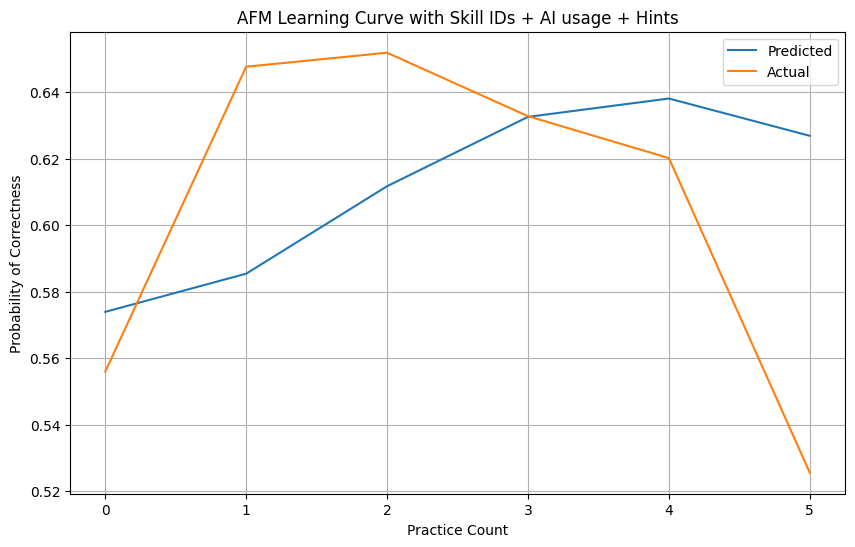

practice_count
0     39876
1     10920
2      4160
3      1664
4       861
5       451
6       230
7       137
8       114
9        70
10       47
11       42
12       40
13       27
14       26
15       23
16       22
17       16
18       14
19       12
20       10
21        9
22        7
23        4
24        3
25        2
26        1
27        1
28        1
29        1
30        1
Name: count, dtype: int64


In [ ]:
#AFM
from sklearn.linear_model import LogisticRegression

def prepare_afm_features(df):
    """Prepare features for AFM modeling."""
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    df['practice_count'] = df.groupby(['user_id', 'skill_id']).cumcount()
    
    if 'hint_used' not in df.columns:
        df['hint_used'] = 0  # No hints for essay
    if 'ai_message_count' not in df.columns:
        df['ai_message_count'] = 0
    
    features = df[['practice_count', 'hint_used', 'ai_message_count', 'skill_id']].copy()
    X = pd.get_dummies(features, columns=['skill_id'])  # One-hot encode skill
    y = df['correct']
    
    return X, y

X_afm, y_afm = prepare_afm_features(all_data_categorical)

afm_model = LogisticRegression(max_iter=1000)
afm_model.fit(X_afm, y_afm)

y_pred_probs = afm_model.predict_proba(X_afm)[:,1]

def plot_learning_curve(X, y_true, y_pred_probs, title="AFM Learning Curve"):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs
    df_plot = df_plot[df_plot['practice_count'] <= 5]
    
    avg_pred = df_plot.groupby('practice_count')['pred'].mean()
    avg_true = df_plot.groupby('practice_count')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index, avg_pred.values, label='Predicted')
    plt.plot(avg_true.index, avg_true.values, label='Actual')
    plt.title(title)
    plt.xlabel('Practice Count')
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_learning_curve(X_afm, y_afm, y_pred_probs, title="AFM Learning Curve with Skill IDs + AI usage + Hints")

print(X_afm['practice_count'].value_counts().sort_index())

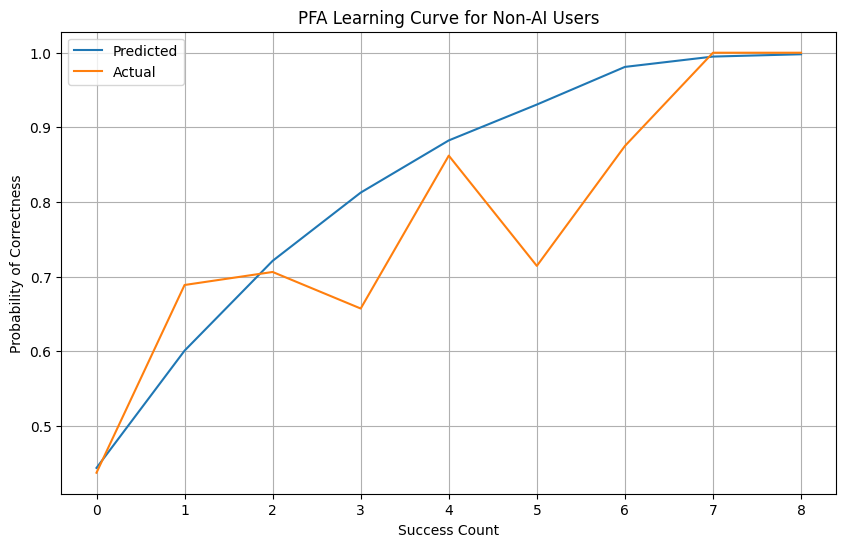

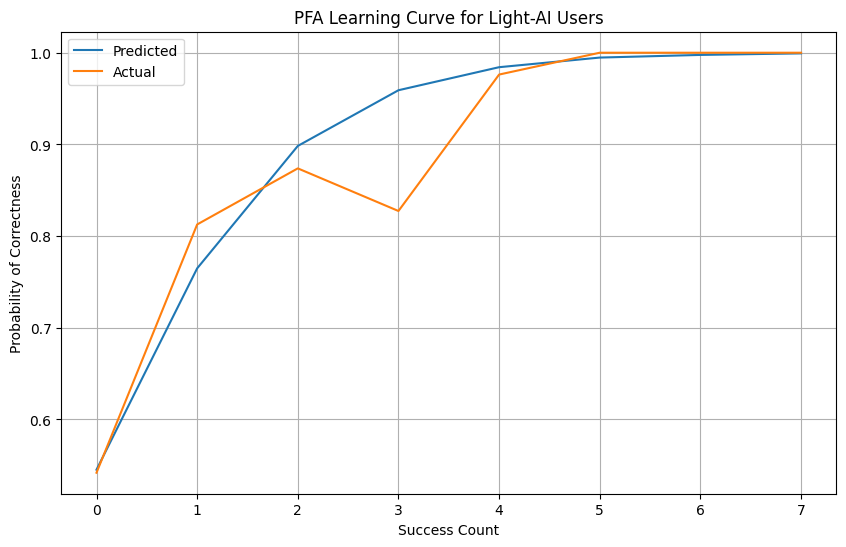

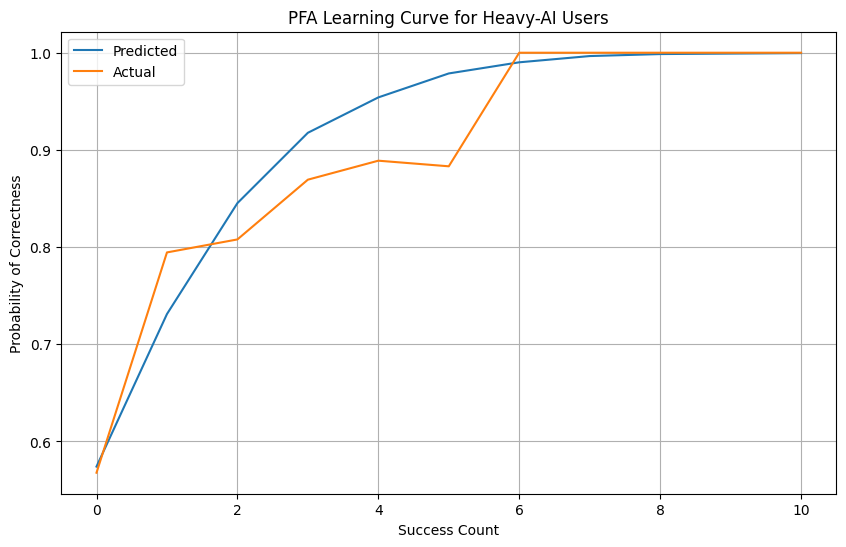

In [ ]:
# PFA
from sklearn.linear_model import LogisticRegression

def prepare_pfa_features(df):
    """Prepare features for PFA modeling."""
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    df['success_count'] = 0
    df['failure_count'] = 0
    user_skill_groups = df.groupby(['user_id', 'skill_id'])
    for (user, skill), group in user_skill_groups:
        successes = 0
        failures = 0
        for idx in group.index:
            df.at[idx, 'success_count'] = successes
            df.at[idx, 'failure_count'] = failures
            if df.at[idx, 'correct'] == 1:
                successes += 1
            else:
                failures += 1
    if 'hint_used' not in df.columns:
        df['hint_used'] = 0
    if 'ai_message_count' not in df.columns:
        df['ai_message_count'] = 0

    feature_cols = ['success_count', 'failure_count', 'hint_used', 'ai_message_count']
    X = df[feature_cols]
    y = df['correct']
    return X, y

non_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'non_ai_user']
light_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'light_ai_user']
heavy_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'heavy_ai_user']

non_ai_data_X, non_ai_data_y = prepare_pfa_features(non_ai_users)
light_ai_data_X, light_ai_data_y = prepare_pfa_features(light_ai_users)
heavy_ai_data_X, heavy_ai_data_y = prepare_pfa_features(heavy_ai_users)

# # All the students together
# X_pfa, y_pfa = prepare_pfa_features(all_data_categorical)

def train_pfa(X, y_true):
    pfa_model = LogisticRegression(max_iter=1000)
    pfa_model.fit(X, y_true)
    y_pred_probs = pfa_model.predict_proba(X)[:,1]
    return y_pred_probs

non_ai_data_y_pred = train_pfa(non_ai_data_X, non_ai_data_y)
light_ai_data_y_pred = train_pfa(light_ai_data_X, light_ai_data_y)
heavy_ai_data_y_pred = train_pfa(heavy_ai_data_X, heavy_ai_data_y)

# Plot 
import matplotlib.pyplot as plt

def plot_pfa_learning_curve(X, y_true, y_pred_probs, title="PFA Learning Curve"):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs

    df_plot = df_plot[df_plot['success_count'] <= 10]  # limit to low success counts where we have data

    avg_pred = df_plot.groupby('success_count')['pred'].mean()
    avg_true = df_plot.groupby('success_count')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index, avg_pred.values, label='Predicted')
    plt.plot(avg_true.index, avg_true.values, label='Actual')
    plt.title(title)
    plt.xlabel('Success Count')
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_pfa_learning_curve(non_ai_data_X, non_ai_data_y, non_ai_data_y_pred, "PFA Learning Curve for Non-AI Users")
plot_pfa_learning_curve(light_ai_data_X, light_ai_data_y, light_ai_data_y_pred, "PFA Learning Curve for Light-AI Users")
plot_pfa_learning_curve(heavy_ai_data_X, heavy_ai_data_y, heavy_ai_data_y_pred, "PFA Learning Curve for Heavy-AI Users")

In [ ]:
# DKT
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Step 1: Prepare DKT sequences
def prepare_dkt_sequences(df):
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    
    # Encode skills into integer indices
    from sklearn.preprocessing import LabelEncoder
    skill_encoder = LabelEncoder()
    df['skill_id_encoded'] = skill_encoder.fit_transform(df['skill_id'])

    sequences = []
    labels = []
    
    grouped = df.groupby('user_id')
    for user, group in grouped:
        skill_seq = group['skill_id_encoded'].tolist()
        correct_seq = group['correct'].tolist()
        combined_seq = [(skill, correct) for skill, correct in zip(skill_seq, correct_seq)]
        sequences.append(combined_seq)

    return sequences, skill_encoder

sequences, skill_encoder = prepare_dkt_sequences(all_data_categorical)

# Encode sequences
n_skills = len(skill_encoder.classes_)
max_seq_len = 100  # max number of interactions per user (can adjust)

X = []
y = []
for seq in sequences:
    input_seq = []
    output_seq = []
    for (skill, correct) in seq:
        input_id = skill + (correct * n_skills)  # clever trick: skill_id + n_skills if correct=1
        input_seq.append(input_id)
        output_seq.append(correct)
    X.append(input_seq)
    y.append(output_seq)

X_pad = pad_sequences(X, maxlen=max_seq_len, padding='post', value=2 * n_skills)  # pad with unknown ID
y_pad = pad_sequences(y, maxlen=max_seq_len, padding='post', value=-1)

# Step 2: Build DKT model
model = Sequential([
    Masking(mask_value=2 * n_skills, input_shape=(max_seq_len,)),
    LSTM(100, return_sequences=True),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam')

# Step 3: Prepare inputs/outputs
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_pad, test_size=0.2, random_state=42)

# DKT expects one-hot inputs
from tensorflow.keras.utils import to_categorical

X_train_onehot = to_categorical(X_train, num_classes=2 * n_skills + 1)
X_test_onehot = to_categorical(X_test, num_classes=2 * n_skills + 1)

# Flatten outputs
y_train_flat = y_train.reshape((-1,))
y_test_flat = y_test.reshape((-1,))
mask_train = y_train_flat != -1
mask_test = y_test_flat != -1

# Train only on valid steps
history = model.fit(X_train_onehot.reshape((-1, max_seq_len, 2 * n_skills + 1)),
                    y_train_flat[mask_train],
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_test_onehot.reshape((-1, max_seq_len, 2 * n_skills + 1)), y_test_flat[mask_test]))

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# EXTRA PLOTS JUST FOR COMPARISON

In [ ]:
# iBKT/individualized-BKT

# 1. First, train a normal BKT model
def train_bkt_basic(df):
    model = Model(seed=42)
    model.fit(data=df)
    return model

# 2. Then, compute per-user average residuals and add a user bias
def train_ibkt(df):
    bkt_model = train_bkt_basic(df)
    preds = bkt_model.predict(data=df)
    df['predicted'] = preds['correct_predictions']
    df['residual'] = df['correct'] - df['predicted']

    user_bias = df.groupby('user_id')['residual'].mean().to_dict()

    return bkt_model, user_bias

# 3. Prediction function
def predict_ibkt(model, user_bias, df):
    preds = model.predict(data=df)
    preds['correct_predictions_ibkt'] = preds['correct_predictions']

    # Add user bias
    preds['correct_predictions_ibkt'] += preds['user_id'].map(user_bias).fillna(0)

    # Clip predictions between [0,1]
    preds['correct_predictions_ibkt'] = preds['correct_predictions_ibkt'].clip(0, 1)

    return preds

# Example usage:
# Prepare data
def prepare_pyBKT_format(df):
    df = df[['user_id', 'skill_id', 'correct']].copy()
    df.columns = ['user_id', 'skill_name', 'correct']
    return df

# Prepare your dataset
filtered_data = all_data_categorical.copy()
filtered_data_simple = prepare_pyBKT_format(filtered_data)

# Train
bkt_model, user_bias = train_ibkt(filtered_data_simple)

# Predict
preds_ibkt = predict_ibkt(bkt_model, user_bias, filtered_data_simple)

/tmp/ipykernel_118/2350771811.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_pred = df_plot.groupby('history_bin')['pred'].mean()
/tmp/ipykernel_118/2350771811.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_true = df_plot.groupby('history_bin')['true'].mean()


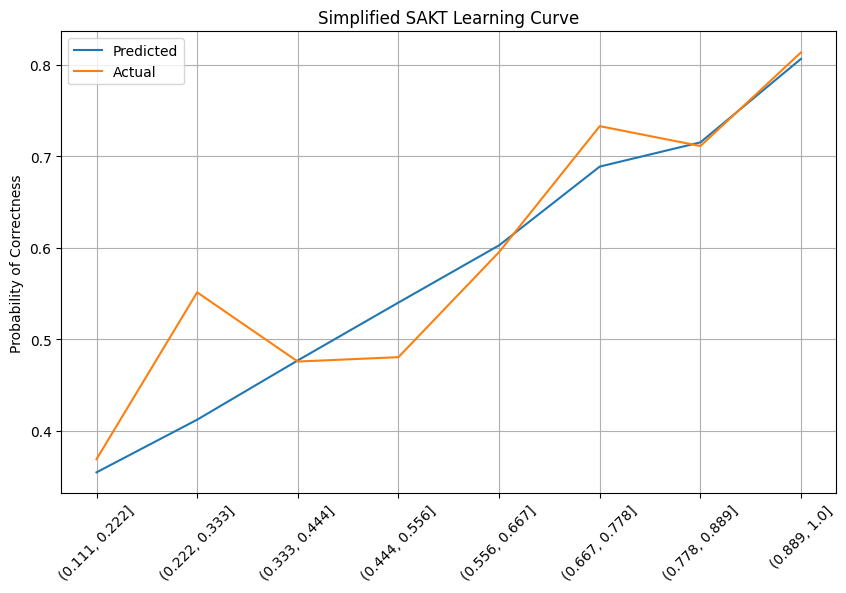

In [ ]:
#Mini-SAKT
from sklearn.linear_model import LogisticRegression

# 1. Prepare interaction history
def prepare_sakt_features(df, window_size=5):
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])

    df['history_correct_mean'] = 0.5  # initialize

    user_groups = df.groupby('user_id')
    for user, group in user_groups:
        correct_history = []
        for idx in group.index:
            if len(correct_history) == 0:
                df.at[idx, 'history_correct_mean'] = 0.5  # no history
            else:
                df.at[idx, 'history_correct_mean'] = np.mean(correct_history[-window_size:])
            correct_history.append(df.at[idx, 'correct'])

    features = df[['history_correct_mean']]
    labels = df['correct']
    return features, labels

# Prepare features
X_sakt, y_sakt = prepare_sakt_features(all_data_categorical)

# 2. Train logistic regression on history
sakt_model = LogisticRegression(max_iter=1000)
sakt_model.fit(X_sakt, y_sakt)

# 3. Predict
y_pred_probs_sakt = sakt_model.predict_proba(X_sakt)[:,1]

# 4. Plot (optional)
import matplotlib.pyplot as plt

def plot_sakt_learning_curve(X, y_true, y_pred_probs):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs

    bins = np.linspace(0, 1, 10)
    df_plot['history_bin'] = pd.cut(df_plot['history_correct_mean'], bins)

    avg_pred = df_plot.groupby('history_bin')['pred'].mean()
    avg_true = df_plot.groupby('history_bin')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index.astype(str), avg_pred.values, label='Predicted')
    plt.plot(avg_true.index.astype(str), avg_true.values, label='Actual')
    plt.xticks(rotation=45)
    plt.title("Simplified SAKT Learning Curve")
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_sakt_learning_curve(X_sakt, y_sakt, y_pred_probs_sakt)

## Task 3: Model Evaluation
In this task, you will use metrics to evaluate your model.

In [ ]:
# Your code for model evaluation goes here

*Your discussion/interpretation about your model's behavior goes here*

## Task 4: Team Reflection
Please describe the contributions of each team member to Milestone 4. Reflect on how you worked as team: what went well, what can be improved for the next milestone?

*Your discussion about team responsibilities goes here*